In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 
import matplotlib as mpl


mpl.rcParams["font.family"] = "serif"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False


In [31]:
import pandas as pd
import re

# --- CONFIGURACIÓN DE VALORES ---
# Ajusta estos valores si tus archivos cambian
VALOR_FACULA_ALTO = 0.4  # Valor numérico cuando aparece '1' en facula
VALOR_SPOT_ALTO = 0.3    # Valor numérico cuando aparece '1' en spot

# --- 1. Cargar archivos ---
chi2_path = r'c:\Proyectos\Astro\AEspectra\exp 3\RetrievalAnal\chi2_log_finale.csv'
times_path = r'c:\Proyectos\Astro\AEspectra\exp 3\RetrievalAnal\Times'

chi2_df = pd.read_csv(chi2_path)
# 'dtype' asegura que '00' se lea como texto. 'sep' maneja espacios múltiples.
times_df = pd.read_csv(times_path, sep=r'\s+', engine='python', dtype={'ffacfspot': str})

# --- 2. Procesar chi2_log ---
def parse_model_name(model_name):
    # Tránsitos
    n_transits_match = re.search(r'(\d+)T', model_name)
    n_transits = int(n_transits_match.group(1)) if n_transits_match else None

    # Tipo (recon/contam)
    model_type_match = re.search(r'(contam|recon|uncontam)', model_name)
    model_type = model_type_match.group(1) if model_type_match else None

    # Spot (Mancha)
    spot_match = re.search(r'([\d\.]+)spot', model_name)
    if spot_match:
        val = spot_match.group(1)
        # Si es '1', asignamos 0.3; si es '0', 0.0; si no, el valor decimal
        spot_fraction = VALOR_SPOT_ALTO if val == '1' else (0.0 if val == '0' else float(val))
    else:
        spot_fraction = 0.0

    # Fácula
    fac_match = re.search(r'([\d\.]+)fac', model_name)
    if fac_match:
        val = fac_match.group(1)
        # Si es '1', asignamos 0.4; si es '0', 0.0
        facula_fraction = VALOR_FACULA_ALTO if val == '1' else (0.0 if val == '0' else float(val))
    else:
        facula_fraction = 0.0

    return n_transits, model_type, spot_fraction, facula_fraction

# Aplicar parseo
chi2_df[['n_transits', 'model_type', 'spot_fraction', 'facula_fraction']] = chi2_df['model_name'].apply(lambda x: pd.Series(parse_model_name(x)))


# --- 3. Procesar Times ---
if 'Mode' in times_df.columns:
    times_df['Mode'] = times_df['Mode'].str.replace('"', '').str.strip()

def parse_ffacfspot_code(code_str):
    code_str = str(code_str).strip()
    if len(code_str) < 2: return 0.0, 0.0
    
    # Primer dígito = Fácula, Segundo dígito = Mancha (Spot)
    facula_fraction = VALOR_FACULA_ALTO if code_str[0] == '1' else 0.0
    spot_fraction = VALOR_SPOT_ALTO if code_str[1] == '1' else 0.0
    
    return facula_fraction, spot_fraction

times_df[['facula_fraction', 'spot_fraction']] = times_df['ffacfspot'].apply(lambda x: pd.Series(parse_ffacfspot_code(x)))

# Renombrar para que coincida con chi2_df
times_df = times_df.rename(columns={'N_T': 'n_transits', 'Mode': 'model_type', 'Time': 'retrieval_time_min'})
times_df = times_df.drop(columns=['ffacfspot'])


# --- 4. Fusión (Merge) ---
# Asegurar tipos enteros para la clave de fusión
chi2_df['n_transits'] = chi2_df['n_transits'].astype(int)
times_df['n_transits'] = times_df['n_transits'].astype(int)

merged_df = pd.merge(chi2_df, times_df, on=['n_transits', 'model_type', 'spot_fraction', 'facula_fraction'], how='left')

# Mostrar resultados
print("Muestra de resultado con Tiempos:")
print(merged_df[['model_name', 'retrieval_time_min']].head(10))

# Guardar
# merged_df.to_csv('c:/Proyectos/Astro/AEspectra/exp 0/Retreival Tests/retrieval_results_final.csv', index=False)

Muestra de resultado con Tiempos:
             model_name  retrieval_time_min
0   recon_1T_0spot-0fac               10.91
1   recon_1T_0spot-1fac               10.80
2   recon_1T_1spot-0fac               11.33
3   recon_1T_1spot-1fac                9.64
4  contam_1T_0spot-0fac               41.05
5  contam_1T_1spot-0fac               53.32
6  contam_1T_1spot-1fac               62.40
7  contam_1T_0spot-1fac               38.18


In [32]:
merged_df

,planet_name,model_name,N,p,dof,MSE,chi2,chi2_reduced,n_transits,model_type,spot_fraction,facula_fraction,retrieval_time_min
0,K2-18b,recon_1T_0spot-0fac,385,11,374,2.836030e-10,30.508704,0.081574,1,recon,0.0,0.0,10.91
1,K2-18b,recon_1T_0spot-1fac,385,11,374,2.077244e-10,50.380271,0.134707,1,recon,0.0,0.4,10.80
2,K2-18b,recon_1T_1spot-0fac,385,11,374,7.436357e-10,285.900477,0.764440,1,recon,0.3,0.0,11.33
3,K2-18b,recon_1T_1spot-1fac,385,11,374,1.460509e-10,29.443495,0.078726,1,recon,0.3,0.4,9.64
4,K2-18b,contam_1T_0spot-0fac,385,11,374,3.042218e-10,31.347601,0.083817,1,contam,0.0,0.0,41.05
5,K2-18b,contam_1T_1spot-0fac,385,11,374,2.090437e-10,29.334564,0.078435,1,contam,0.3,0.0,53.32
6,K2-18b,contam_1T_1spot-1fac,385,11,374,5.552986e-10,100.654063,0.269129,1,contam,0.3,0.4,62.40
7,K2-18b,contam_1T_0spot-1fac,385,11,374,3.711100e-10,63.045815,0.168572,1,contam,0.0,0.4,38.18


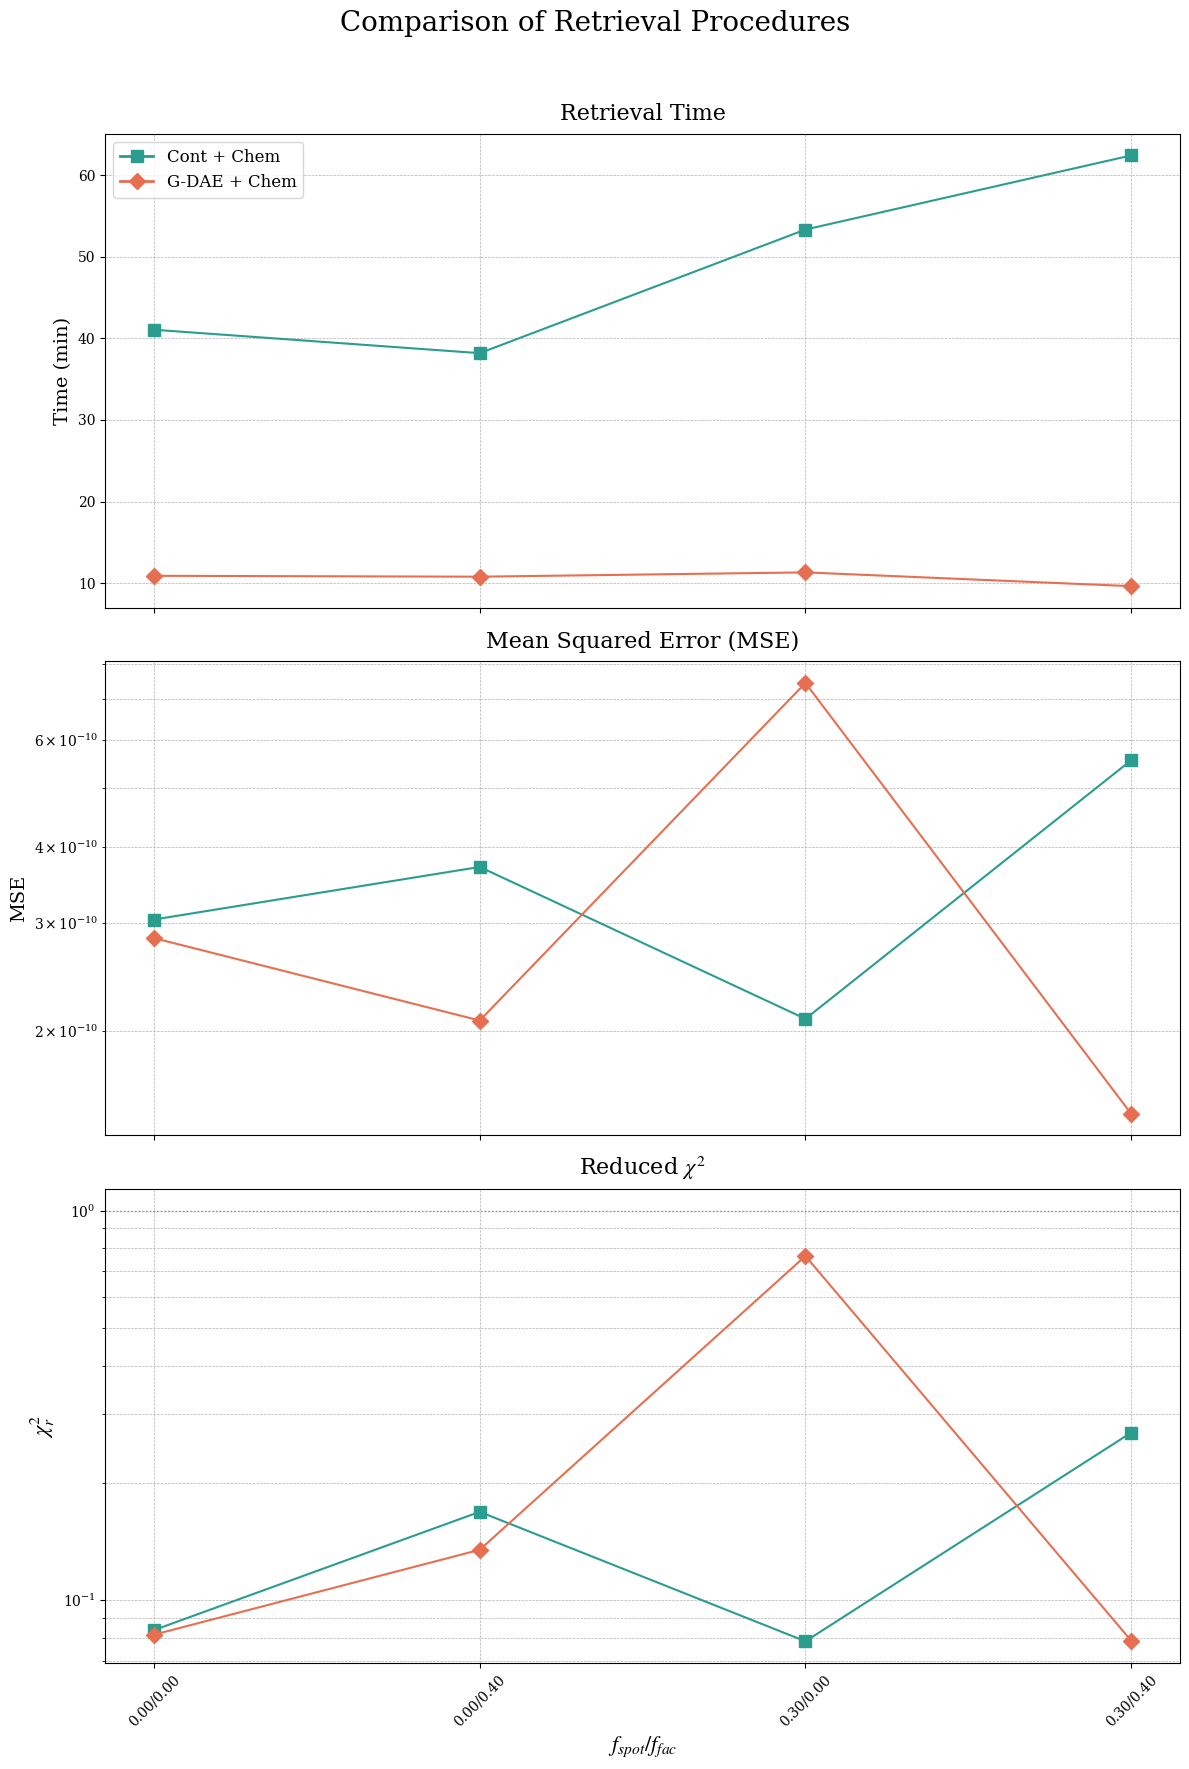

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Necesario si no está cargado
from matplotlib.lines import Line2D

# --- Aseguramos que merged_df existe (Usamos el que creamos antes) ---
# Si cerraste la sesión, asegúrate de correr el bloque de fusión anterior primero.

# --- CONFIGURACIÓN ESTÉTICA ---
PALETTE = {
    "contam":   "#2A9D8F",  # teal
    "recon":    "#E76F51",  # apricot
}

MARKERS = {
    "uncontam": "o",  # círculo
    "contam":   "s",  # cuadrado
    "recon":    "D",  # rombo
}

LEGEND_LABELS = {
    "uncontam": "Chem",
    "contam":   "Cont + Chem",
    "recon":    "G-DAE + Chem",
}

# --- PREPARACIÓN DE DATOS PARA PLOT ---
# Etiqueta x formateada
def frac_label(row):
    return f"{row['spot_fraction']:.2f}/{row['facula_fraction']:.2f}"

merged_df["x_label"] = merged_df.apply(frac_label, axis=1)

# Ordenamos eje X por (spot, facula)
x_labels = sorted(
    list(merged_df["x_label"].unique()),
    key=lambda x: (float(x.split("/")[0]), float(x.split("/")[1])),
)
x_ticks = np.arange(len(x_labels))

# --- PLOTTING ---
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)
fig.suptitle("Comparison of Retrieval Procedures", fontsize=20)

model_order = ["contam", "recon"]

for model_type in model_order:
    # Obtener estilo
    m = MARKERS.get(model_type, 'o')
    color = PALETTE.get(model_type, 'black')
    
    # Filtrar por modelo
    model_df = merged_df[merged_df["model_type"] == model_type]

    # --- CAMBIO IMPORTANTE AQUÍ: n_transits == 1 ---
    # Tus datos corregidos tienen n_transits = 1.
    sub_1t = model_df[model_df["n_transits"] == 1]
    
    if not sub_1t.empty:
        # Agrupar y reindexar para alinear con el eje X
        df_1t = (sub_1t.groupby("x_label")[["retrieval_time_min", "MSE", "chi2_reduced"]]
                 .mean()
                 .reindex(x_labels)
                 .reset_index())
        
        # Graficar solo si hay datos válidos
        if not df_1t["retrieval_time_min"].isnull().all():
            # Subplot 0: Time
            axes[0].plot(x_ticks, df_1t["retrieval_time_min"], color=color, linestyle="-", marker=m, markersize=8, label=LEGEND_LABELS.get(model_type, model_type))
            # Subplot 1: MSE
            axes[1].plot(x_ticks, df_1t["MSE"],                color=color, linestyle="-", marker=m, markersize=8)
            # Subplot 2: Chi2
            axes[2].plot(x_ticks, df_1t["chi2_reduced"],       color=color, linestyle="-", marker=m, markersize=8)

# --- CONFIGURACIÓN DE EJES ---
axes[0].set_ylabel("Time (min)", fontsize=14)
axes[0].set_title("Retrieval Time", pad=10, fontsize=16)
axes[0].grid(True, which="both", linestyle="--", linewidth=0.5)

axes[1].set_ylabel("MSE", fontsize=14)
axes[1].set_title("Mean Squared Error (MSE)", pad=10, fontsize=16)
axes[1].set_yscale("log")
axes[1].grid(True, which="both", linestyle="--", linewidth=0.5)

axes[2].set_ylabel(r"$\chi^2_r$", fontsize=16)
axes[2].set_title(r"Reduced $\chi^2$", fontsize=16, pad=10)
axes[2].set_yscale("log")
axes[2].grid(True, which="both", linestyle="--", linewidth=0.5)
axes[2].axhline(1.0, color="gray", lw=1, ls=":", alpha=0.8)

# Eje X compartido al final
plt.xlabel(r"$f_{spot} / f_{fac}$", fontsize=16)
plt.xticks(ticks=x_ticks, labels=x_labels, rotation=45)

# --- LEYENDA ---
# Creamos la leyenda manualmente para tener control total
legend_elements = [
    Line2D([0], [0], color=PALETTE[mt], lw=2, marker=MARKERS[mt], markersize=8, label=LEGEND_LABELS[mt])
    for mt in model_order
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Guardar
plt.savefig("retrieval_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Recuperaciones

In [34]:
import re
from pathlib import Path
from typing import Dict, List, Optional
import pandas as pd
import numpy as np

# --- CONFIGURACIÓN DE VALORES ---
VALOR_FACULA_ALTO = 0.4  # Valor real cuando dice "1fac"
VALOR_SPOT_ALTO = 0.3    # Valor real cuando dice "1spot"

# Patrón numérico robusto
NUM = r'[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?'

# Regex para el nombre del modelo
MODEL_REGEX = re.compile(
    r'^(?P<model_type>contam|recon|uncontam)_(?P<n_transits>\d+)T_(?P<spot_fraction>\d+(?:\.\d+)?)spot-(?P<facula_fraction>\d+(?:\.\d+)?)fac$'
)

# --- CAMBIO AQUÍ: O3 -> NH3 ---
# Línea típica dentro del bloque 1 sigma
PARAM_LINE_1SIGMA = re.compile(
    rf'^\s*log_(?P<gas>H2O|CH4|CO2|NH3)\s*=\s*(?P<val>{NUM})\s*\(\+(?P<plus>{NUM})\)\s*\(\-(?P<minus>{NUM})\)\s*$'
)

def read_text_safely(path: Path) -> str:
    """Intenta varias codificaciones para evitar errores con símbolos como sigma."""
    for enc in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return path.read_text(encoding=enc)
        except Exception:
            continue
    return path.read_bytes().decode("latin-1", errors="ignore")

def parse_model_block(text: str) -> Dict[str, object]:
    """
    Extrae la línea 'Model:' y parsea el nombre aplicando la lógica de conversión:
    1spot -> 0.3, 1fac -> 0.4.
    """
    model_line = None
    for line in text.splitlines():
        if line.strip().startswith("Model:"):
            model_line = line.split("Model:", 1)[1].strip()
            break
            
    out: Dict[str, object] = {"model_name": model_line}
    
    if model_line:
        m = MODEL_REGEX.match(model_line)
        if m:
            # --- Lógica de Corrección de Fracciones ---
            raw_spot = m.group("spot_fraction")
            if raw_spot == '1':
                spot_val = VALOR_SPOT_ALTO
            elif raw_spot == '0':
                spot_val = 0.0
            else:
                spot_val = float(raw_spot)

            raw_fac = m.group("facula_fraction")
            if raw_fac == '1':
                fac_val = VALOR_FACULA_ALTO
            elif raw_fac == '0':
                fac_val = 0.0
            else:
                fac_val = float(raw_fac)
            # ------------------------------------------

            out.update({
                "model_type": m.group("model_type"),
                "n_transits": int(m.group("n_transits")),
                "spot_fraction": spot_val,
                "facula_fraction": fac_val,
            })
        else:
            out.update({
                "model_type": None, "n_transits": np.nan,
                "spot_fraction": np.nan, "facula_fraction": np.nan,
            })
    else:
        out.update({
            "model_type": None, "n_transits": np.nan,
            "spot_fraction": np.nan, "facula_fraction": np.nan,
        })
    return out

def find_block_lines_1sigma(text: str) -> List[str]:
    """Detecta el bloque de '1 sigma constraints'."""
    lines = text.splitlines()
    start_idx = None
    pat = re.compile(r'^\s*1[^\n]*constraints\b', flags=re.IGNORECASE)
    
    for i, line in enumerate(lines):
        if pat.search(line):
            start_idx = i
            break
            
    if start_idx is None:
        return []
        
    i = start_idx + 1
    while i < len(lines) and "=" not in lines[i]:
        i += 1
        
    collected = []
    while i < len(lines):
        s = lines[i].strip()
        if (not s) or s.startswith("***") or s.startswith("###") or s.startswith("---") or s.startswith("___"):
            break
        collected.append(s)
        i += 1
    return collected

def parse_params_from_lines(lines: List[str]) -> Dict[str, Dict[str, float]]:
    out: Dict[str, Dict[str, float]] = {}
    for line in lines:
        m = PARAM_LINE_1SIGMA.match(line)
        if not m:
            continue
        gas   = m.group("gas")
        val   = float(m.group("val"))
        plus  = float(m.group("plus"))
        minus = float(m.group("minus"))
        out[gas] = {"val": val, "min1s": val - minus, "max1s": val + plus}
    return out

def fallback_parse_smallest_uncertainty(text: str) -> Dict[str, Dict[str, float]]:
    out: Dict[str, Dict[str, float]] = {}
    best_errsum: Dict[str, float] = {}
    
    for raw in text.splitlines():
        m = PARAM_LINE_1SIGMA.match(raw.strip())
        if not m:
            continue
        gas   = m.group("gas")
        val   = float(m.group("val"))
        plus  = float(m.group("plus"))
        minus = float(m.group("minus"))
        errsum = abs(plus) + abs(minus)
        
        if (gas not in best_errsum) or (errsum < best_errsum[gas]):
            best_errsum[gas] = errsum
            out[gas] = {"val": val, "min1s": val - minus, "max1s": val + plus}
    return out

def parse_poseidon_file(path: Path) -> Dict[str, object]:
    text = read_text_safely(path)
    meta = parse_model_block(text)

    # 1) Intento estándar: bloque 1 sigma
    block_lines = find_block_lines_1sigma(text)
    one_sigma = parse_params_from_lines(block_lines)

    # 2) Fallback
    if not one_sigma:
        one_sigma = fallback_parse_smallest_uncertainty(text)

    row: Dict[str, object] = {"file": str(path)}
    row.update(meta)

    # --- CAMBIO AQUÍ: O3 -> NH3 ---
    for gas in ["CO2", "CH4", "NH3", "H2O"]:
        g = one_sigma.get(gas, {})
        row[f"log_{gas}"]        = g.get("val",   np.nan)
        row[f"log_{gas}_min1s"]  = g.get("min1s", np.nan)
        row[f"log_{gas}_max1s"]  = g.get("max1s", np.nan)
    return row

def collect_poseidon_results_recovered_minmax(base_dir: Path) -> pd.DataFrame:
    files = sorted(base_dir.rglob("*_results.txt"))
    rows = [parse_poseidon_file(p) for p in files]
    df = pd.DataFrame(rows)

    # Orden de columnas
    meta_cols = ["file", "model_name", "model_type", "n_transits", "spot_fraction", "facula_fraction"]
    gas_cols = []
    
    # --- CAMBIO AQUÍ: O3 -> NH3 ---
    for gas in ["CO2", "CH4", "NH3", "H2O"]:
        gas_cols += [f"log_{gas}", f"log_{gas}_min1s", f"log_{gas}_max1s"]

    ordered = [c for c in meta_cols if c in df.columns] + [c for c in gas_cols if c in df.columns]
    others  = [c for c in df.columns if c not in ordered]
    df = df[ordered + others]

    # Tipos de datos
    if "n_transits" in df.columns:
        try:
            df["n_transits"] = df["n_transits"].astype("Int64")
        except Exception:
            pass
    for col in ["spot_fraction", "facula_fraction"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            
    return df

In [35]:
# === Ejecuta el colector sobre tu carpeta local ===
from pathlib import Path

# Cambia esta ruta por la tuya (raw string para Windows)
BASE_DIR = Path(r"POSEIDON_output\K2-18b\retrievals")

df = collect_poseidon_results_recovered_minmax(BASE_DIR)

# Guarda el CSV junto a tus resultados
OUT_CSV = BASE_DIR / "retrieved_gases_recovered_minmax.csv"
df.to_csv(OUT_CSV, index=False)

print(f"Archivos procesados: {len(df)} filas")
print(f"CSV guardado en: {OUT_CSV}")
print()
print(df.head(12).to_string(index=False))


Archivos procesados: 10 filas
CSV guardado en: POSEIDON_output\K2-18b\retrievals\retrieved_gases_recovered_minmax.csv

                                                                      file           model_name model_type  n_transits  spot_fraction  facula_fraction  log_CO2  log_CO2_min1s  log_CO2_max1s  log_CH4  log_CH4_min1s  log_CH4_max1s  log_NH3  log_NH3_min1s  log_NH3_max1s  log_H2O  log_H2O_min1s  log_H2O_max1s
POSEIDON_output\K2-18b\retrievals\results\contam_1T_0spot-0fac_results.txt contam_1T_0spot-0fac     contam           1            0.0              0.0    -4.33          -4.83          -3.86    -2.35          -2.56          -2.15    -4.74          -4.98          -4.49    -5.33          -6.38          -4.37
POSEIDON_output\K2-18b\retrievals\results\contam_1T_0spot-1fac_results.txt contam_1T_0spot-1fac     contam           1            0.0              0.4    -3.52          -3.98          -3.12    -2.07          -2.24          -1.92    -6.02          -6.60          -5.52

In [36]:
#delete rows with NaN values
df = df.dropna()



df[df['model_type'] == 'uncontam']


,file,model_name,model_type,n_transits,spot_fraction,facula_fraction,log_CO2,log_CO2_min1s,log_CO2_max1s,log_CH4,log_CH4_min1s,log_CH4_max1s,log_NH3,log_NH3_min1s,log_NH3_max1s,log_H2O,log_H2O_min1s,log_H2O_max1s


In [37]:
df

,file,model_name,model_type,n_transits,spot_fraction,facula_fraction,log_CO2,log_CO2_min1s,log_CO2_max1s,log_CH4,log_CH4_min1s,log_CH4_max1s,log_NH3,log_NH3_min1s,log_NH3_max1s,log_H2O,log_H2O_min1s,log_H2O_max1s
0,POSEIDON_output\K2-18b\retrievals\results\cont...,contam_1T_0spot-0fac,contam,1,0.0,0.0,-4.33,-4.83,-3.86,-2.35,-2.56,-2.15,-4.74,-4.98,-4.49,-5.33,-6.38,-4.37
1,POSEIDON_output\K2-18b\retrievals\results\cont...,contam_1T_0spot-1fac,contam,1,0.0,0.4,-3.52,-3.98,-3.12,-2.07,-2.24,-1.92,-6.02,-6.60,-5.52,-4.85,-5.88,-4.14
2,POSEIDON_output\K2-18b\retrievals\results\cont...,contam_1T_1spot-0fac,contam,1,0.3,0.0,-3.56,-4.39,-2.91,-1.79,-1.98,-1.62,-5.94,-6.60,-5.33,-3.68,-4.49,-3.15
3,POSEIDON_output\K2-18b\retrievals\results\cont...,contam_1T_1spot-1fac,contam,1,0.3,0.4,-3.70,-4.16,-3.25,-1.67,-1.83,-1.52,-6.02,-6.62,-5.44,-3.76,-4.95,-3.15
4,POSEIDON_output\K2-18b\retrievals\results\reco...,recon_1T_0spot-0fac,recon,1,0.0,0.0,-4.12,-4.62,-3.64,-2.26,-2.47,-2.06,-4.72,-5.01,-4.44,-5.41,-6.48,-4.35
5,POSEIDON_output\K2-18b\retrievals\results\reco...,recon_1T_0spot-1fac,recon,1,0.0,0.4,-4.02,-5.07,-3.12,-2.22,-2.49,-1.99,-5.36,-6.16,-4.89,-2.35,-2.73,-2.12
6,POSEIDON_output\K2-18b\retrievals\results\reco...,recon_1T_1spot-0fac,recon,1,0.3,0.0,-6.09,-6.65,-5.60,-4.02,-4.17,-3.87,-6.67,-6.89,-6.39,-6.29,-6.78,-5.69
7,POSEIDON_output\K2-18b\retrievals\results\reco...,recon_1T_1spot-1fac,recon,1,0.3,0.4,-2.04,-2.29,-1.85,-1.99,-2.16,-1.82,-5.77,-6.47,-5.19,-5.25,-6.44,-4.03
8,POSEIDON_output\K2-18b\retrievals\results\reco...,recon_5T_0spot-0fac,recon,5,0.0,0.0,-2.70,-2.92,-2.51,-1.78,-1.86,-1.70,-5.47,-5.77,-5.22,-5.17,-6.30,-4.28
9,POSEIDON_output\K2-18b\retrievals\results\reco...,recon_5T_0spot-1fac,recon,5,0.0,0.4,-2.74,-2.97,-2.53,-1.81,-1.90,-1.73,-5.50,-5.84,-5.24,-4.31,-5.23,-3.78


✅ Graficando 8 modelos con n_transits=1.
Gráfico guardado en: retrieval_vmr_comparison_NH3_final.png


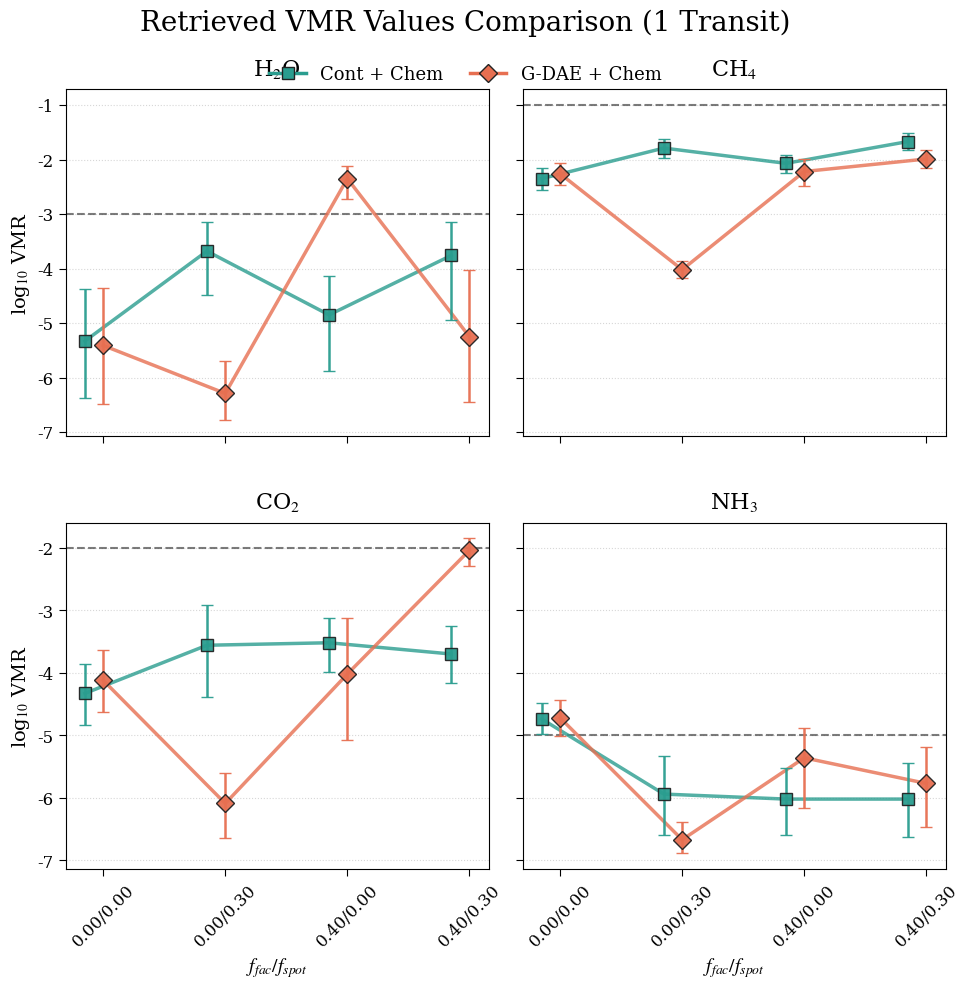

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ==========================================
# === 1. CONFIGURACIÓN DE ESTILO ===
# ==========================================
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

# Parámetros visuales
LINE_WIDTH = 2.5       
MARKER_SIZE = 9        
EDGE_COLOR = "#222222" 
ERROR_BAR_WIDTH = 1.8  

# Paleta de colores
PALETTE = {
    "uncontam": "#E9C46A",  # Amarillo
    "contam":   "#2A9D8F",  # Verde azulado
    "recon":    "#E76F51",  # Rojo/Naranja
}

# Formas geométricas
MARKERS = {
    "uncontam": "o", 
    "contam":   "s", 
    "recon":    "D", 
}

# Etiquetas
LEGEND_LABELS = {
    "uncontam": "Chem",
    "contam":   "Cont + Chem",
    "recon":    "G-DAE + Chem",
}

# Desplazamiento horizontal para que no se solapen
FAM_OFFSETS = {"contam": -0.15, "recon": 0.0, "uncontam": +0.15}

# ==========================================
# === VALORES DE REFERENCIA (EXPECTED) ===
# ==========================================
# Valores actualizados según tu solicitud:
EXPECTED = {
    "CH4": -1.0,
    "CO2": -2.0,
    "H2O": -3.0,
    "NH3": -5.0
}

# ==========================================
# === 2. PREPARACIÓN DE DATOS ===
# ==========================================
# Asumimos que el DataFrame se llama 'df'

# Filtramos SOLO 1 tránsito (según tus archivos '1T')
plot_df = df[df["n_transits"] == 1].copy()

if plot_df.empty:
    print("⚠️ ALERTA: El DataFrame filtrado está vacío. Verifica que 'n_transits' sea 1 en tu 'df'.")
else:
    print(f"✅ Graficando {len(plot_df)} modelos con n_transits=1.")

# Asegurar tipos numéricos para el formateo
plot_df["facula_fraction"] = pd.to_numeric(plot_df["facula_fraction"], errors='coerce')
plot_df["spot_fraction"]   = pd.to_numeric(plot_df["spot_fraction"], errors='coerce')

# Crear etiqueta ratio (Fac/Spot)
plot_df["ratio"] = (
    plot_df["facula_fraction"].map(lambda v: f"{v:.2f}") + "/" +
    plot_df["spot_fraction"].map(lambda v: f"{v:.2f}")
)

# Ordenar lógicamente el eje X
unique_ratios = plot_df[["facula_fraction", "spot_fraction", "ratio"]].drop_duplicates()
unique_ratios = unique_ratios.sort_values(by=["facula_fraction", "spot_fraction"])
order = unique_ratios["ratio"].tolist()

_pos_map = {lab: i for i, lab in enumerate(order)}
plot_df["xpos"] = plot_df["ratio"].map(_pos_map)

# ==========================================
# === 3. FUNCIÓN DE PLOTEO ===
# ==========================================
def plot_gas(ax, gas, data):
    y     = f"log_{gas}"
    y_min = f"log_{gas}_min1s"
    y_max = f"log_{gas}_max1s"

    # Línea de referencia (Expected)
    if gas in EXPECTED:
        ax.axhline(EXPECTED[gas], linestyle="--", linewidth=1.5, color="#444", alpha=0.7, zorder=1)

    if y not in data.columns: return
    gdf = data[np.isfinite(data[y])].copy()
    if gdf.empty: return

    # Grid
    ax.set_axisbelow(True)
    ax.grid(True, which="major", axis="y", alpha=0.5, linestyle=":", linewidth=0.8)

    model_order = ["uncontam", "contam", "recon"]
    
    for fam in model_order:
        sub = gdf[gdf["model_type"] == fam]
        if sub.empty: continue

        color  = PALETTE.get(fam, "#555")
        marker = MARKERS.get(fam, 'o')

        sub_sorted = sub.sort_values("xpos")
        x = sub_sorted["xpos"].values + FAM_OFFSETS.get(fam, 0.0)
        yv = sub_sorted[y].values

        # Barras de error (Poseidon da min/max absolutos, convertimos a relativos)
        if y_min in sub_sorted.columns and y_max in sub_sorted.columns:
            err_low = yv - sub_sorted[y_min].values
            err_high = sub_sorted[y_max].values - yv
            # Evitar errores negativos por redondeo
            err_low = np.maximum(0, err_low)
            err_high = np.maximum(0, err_high)
            yerr = np.vstack([err_low, err_high])
        else:
            yerr = np.zeros((2, len(yv)))

        # 1. Líneas conectoras
        if len(x) > 1:
            ax.plot(x, yv, linestyle="-", linewidth=LINE_WIDTH, color=color, alpha=0.8, zorder=2)

        # 2. Marcadores y Errores
        ax.errorbar(
            x, yv, yerr=yerr,
            fmt=marker, ms=MARKER_SIZE,
            capsize=4, capthick=ERROR_BAR_WIDTH*0.8, elinewidth=ERROR_BAR_WIDTH,
            color=color, markerfacecolor=color,
            markeredgecolor=EDGE_COLOR, markeredgewidth=1.0,
            linestyle="None", label=LEGEND_LABELS.get(fam, fam),
            alpha=0.95, zorder=3
        )

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=0, ha="center")

# ==========================================
# === 4. CREACIÓN DE FIGURA ===
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex='col', sharey='row')
fig.subplots_adjust(top=0.88, bottom=0.10, left=0.10, right=0.98, wspace=0.08, hspace=0.25)

fig.suptitle("Retrieved VMR Values Comparison (1 Transit)", fontsize=20, y=0.96)

axes_flat = axes.ravel()
# Lista con NH3
gases_to_plot = ["H2O", "CH4", "CO2", "NH3"]
gas_titles    = {"H2O": r"H$_2$O", "CH4": r"CH$_4$", "CO2": r"CO$_2$", "NH3": r"NH$_3$"}

for ax, gas in zip(axes_flat, gases_to_plot):
    plot_gas(ax, gas, plot_df)
    ax.set_title(gas_titles[gas], fontsize=16, pad=10)

# Etiquetas de Ejes y Ajustes Y
# El rango Y se ajusta dinámicamente, pero puedes forzarlo si quieres (ej. set_ylim(-6, -1))
for i in range(2):
    for j in range(2):
        axes[i, j].tick_params(labelsize=12, length=5)
        if j == 0: axes[i, j].set_ylabel(r"log$_{10}$ VMR", fontsize=14)
        if i == 1: 
            axes[i, j].set_xlabel(r"$f_{fac}/f_{spot}$", fontsize=14)
            axes[i, j].tick_params(axis='x', rotation=45)

# Limpieza de ticks
for ax in axes[:, 0]: ax.tick_params(axis='y', labelleft=True)
for ax in axes[:, 1]: ax.tick_params(axis='y', labelleft=False)
for ax in axes[0, :]: ax.tick_params(axis='x', labelbottom=False) 
for ax in axes[1, :]: ax.tick_params(axis='x', labelbottom=True)

# ==========================================
# === 5. LEYENDA ===
# ==========================================
present_fams = [f for f in ["uncontam", "contam", "recon"] if f in plot_df["model_type"].unique()]
legend_handles = [
    Line2D([0], [0], marker=MARKERS[f], linestyle='-', linewidth=LINE_WIDTH, 
           color=PALETTE[f], markerfacecolor=PALETTE[f], markeredgecolor=EDGE_COLOR, 
           markersize=MARKER_SIZE, label=LEGEND_LABELS[f]) for f in present_fams
]

if legend_handles:
    fig.legend(
        handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.92), 
        ncols=len(legend_handles), frameon=False, fontsize=13, columnspacing=1.5
    )

# Guardar y Mostrar
out_img = "retrieval_vmr_comparison_NH3_final.png"
plt.savefig(out_img, dpi=300, bbox_inches="tight")
print(f"Gráfico guardado en: {out_img}")
plt.show()